Mounted at /content/drive
Copied -> /content/Assignment_Part1.ipynb
Copied -> /content/Assignment_Part2.ipynb
Copied -> /content/Assignment_part3.ipynb
Copied -> /content/AirQualityDataset.csv
Copied -> /content/epa2021.csv
Copied -> /content/recipe_reviews.csv

Now in /content:
['.config', 'AirQualityDataset.csv', 'Assignment_Part1.ipynb', 'Assignment_Part1.py', 'Assignment_Part1.txt', 'Assignment_Part2.ipynb', 'Assignment_Part2.py', 'Assignment_part3.ipynb', 'Assignment_part3.py', 'Python_1.py', 'city_mpg_heatmap.pdf', 'drive', 'epa2021.csv', 'recipe_reviews.csv', 'sample_data', 'sleep_tracking_toolkit', 'sleep_tracking_toolkit.zip', 'transmission_analysis.csv']
Converted Assignment_Part1.ipynb -> Assignment_Part1.py
Converted Assignment_Part2.ipynb -> Assignment_Part2.py
Converted Assignment_part3.ipynb -> Assignment_part3.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unique Value Counts:
mfr_name: 22
class: 22
fuel_usage_desc: 6


<Figure size 640x480 with 0 Axes>

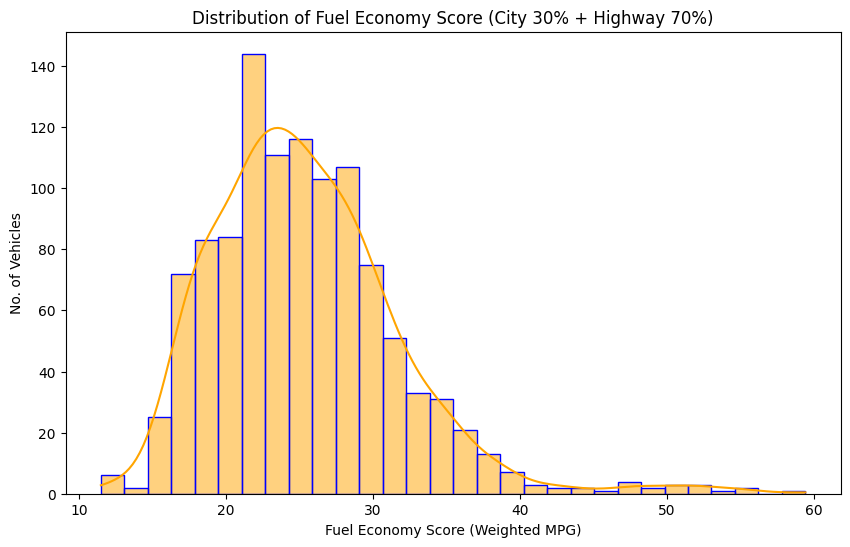

/content/Assignment_part3.py:225: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_mpg_by_bin = df.groupby("displacement_bin")["comb_mpg"].mean().reset_index()
/content/Assignment_part3.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mpg_by_bin, x="displacement_bin", y="comb_mpg", palette="Oranges")


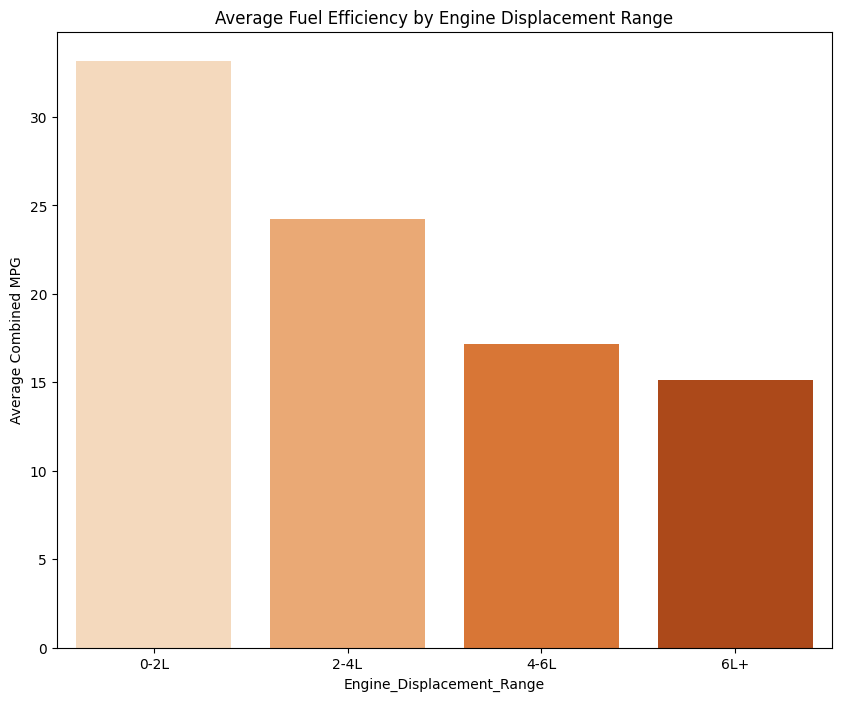

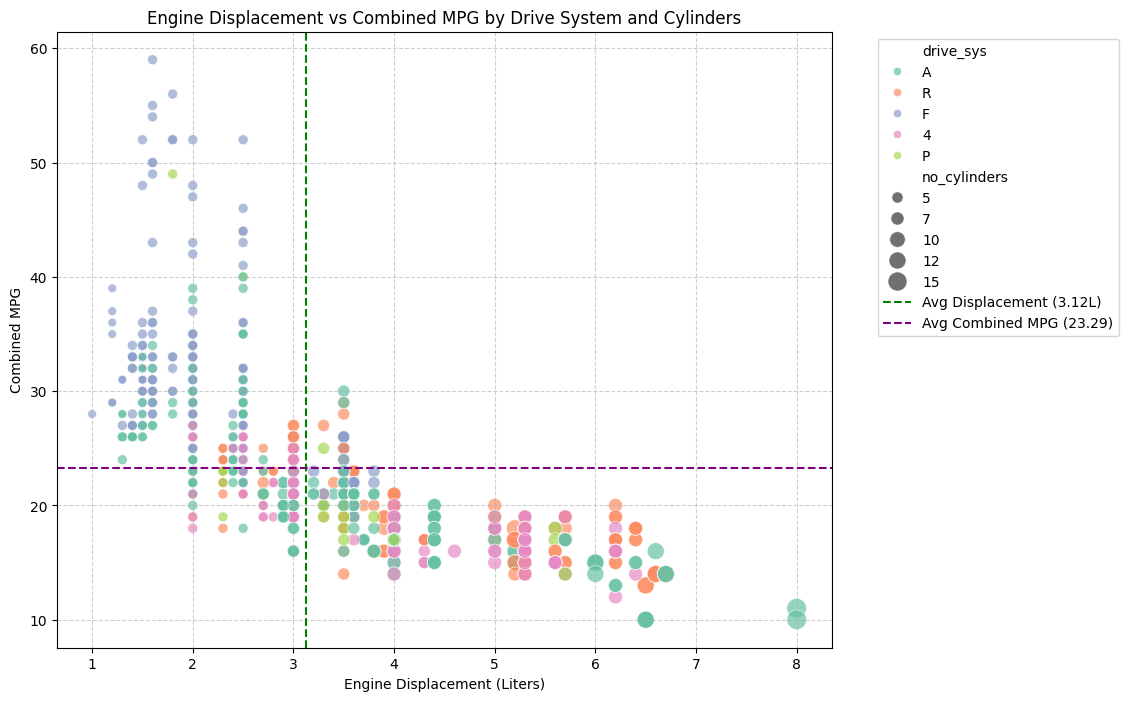

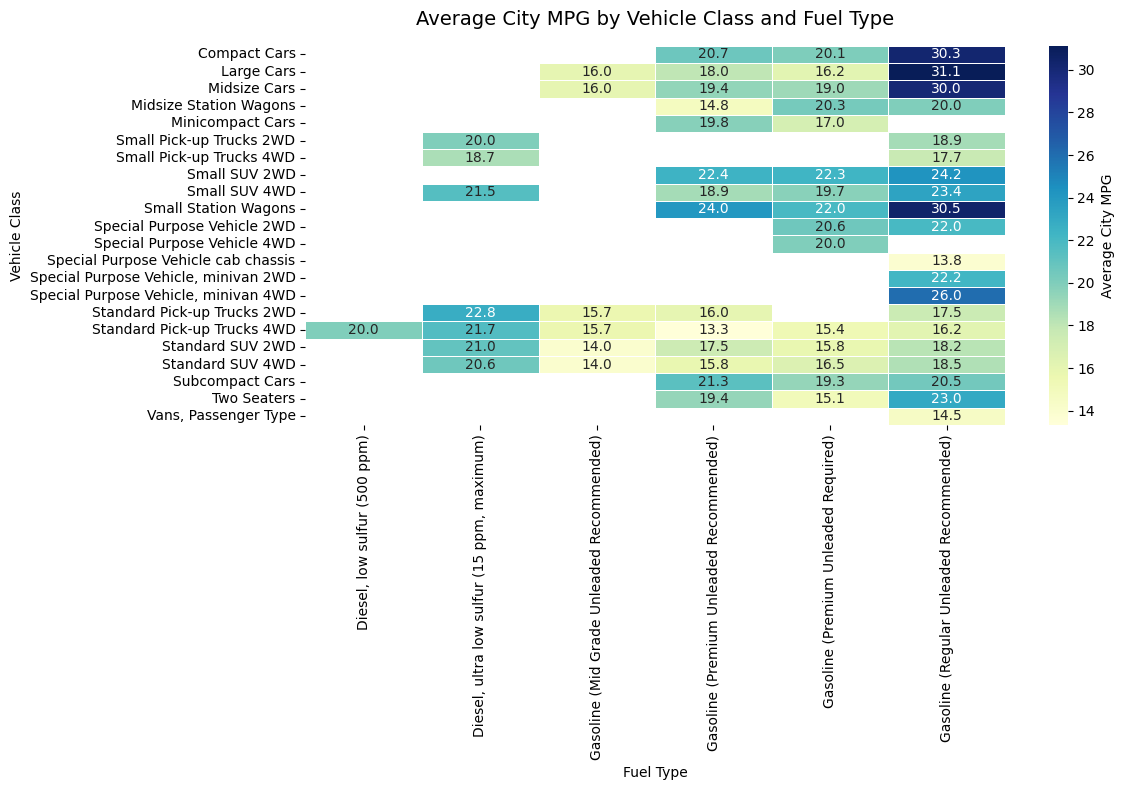

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, shutil, nbformat
from nbconvert import PythonExporter

# 2) Paths
project_path = "/content/drive/MyDrive/Final_Project"

# 3) Connect files from Drive
files_to_copy = [
    "Assignment_Part1.ipynb",
    "Assignment_Part2.ipynb",
    "Assignment_part3.ipynb",
    "AirQualityDataset.csv",
    "epa2021.csv",
    "recipe_reviews.csv",
]

for fname in files_to_copy:
    src = os.path.join(project_path, fname)
    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing in Drive: {src}")
    shutil.copy2(src, "/content")
    print(f"Copied -> /content/{fname}")

print("\nNow in /content:")
print(sorted(os.listdir("/content")))

# 4) Convert notebooks to .py so %run works
exporter = PythonExporter()
for nb_name in ["Assignment_Part1.ipynb", "Assignment_Part2.ipynb", "Assignment_part3.ipynb"]:
    with open(nb_name, "r", encoding="utf-8") as f:
        nb_node = nbformat.read(f, as_version=4)
    code, _ = exporter.from_notebook_node(nb_node)
    py_name = nb_name.replace(".ipynb", ".py")
    with open(py_name, "w", encoding="utf-8") as f:
        f.write(code)
    print(f"Converted {nb_name} -> {py_name}")

# 5) Run the generated .py files
%run Assignment_Part1.py
%run Assignment_Part2.py
%run Assignment_part3.py


#**PART-4**

In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("recipe_reviews.csv")

# Define the target column (adjust if different)
TARGET = "stars"


# Data Cleaning

# 1) Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed duplicates: {before - len(df)}")

# 2) Replace placeholder '2' with NaN in non-target *object* columns
obj_cols = [c for c in df.columns if df[c].dtype == "O" and c != TARGET]
if obj_cols:
    df[obj_cols] = df[obj_cols].apply(lambda s: s.replace({"2": np.nan}))

# If you know specific numeric columns where 2 means "missing", list them here:
NUM_PLACEHOLDER_COLS = []
if NUM_PLACEHOLDER_COLS:
    df[NUM_PLACEHOLDER_COLS] = df[NUM_PLACEHOLDER_COLS].replace(2, np.nan)

# 3) Coerce dtypes where possible
for c in df.columns:
    if c == TARGET:
        continue
    # Try numeric first; if nothing changes it stays as-is
    coerced = pd.to_numeric(df[c], errors="ignore")
    df[c] = coerced

# 3a) Normalize categorical text
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    s = s.replace({"": np.nan, "na": np.nan, "none": np.nan, "null": np.nan})
    df[c] = s.str.lower()

# 3b) Create review_length if missing
if "review_length" not in df.columns:
    text_col = next((c for c in ["text", "review_text", "content", "body", "comment"] if c in df.columns), None)
    if text_col:
        df["review_length"] = df[text_col].fillna("").astype(str).str.len()

# 4) Missing values overview
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts.head(15).to_frame("missing_count"))

# Adjust the list if you want different columns filled
to_fill_as_unknown = [c for c in ["region", "device_type", "recipe_name", "comment_id",
                                  "user_id", "user_name", "text"]
                      if c in df.columns]
for col in to_fill_as_unknown:
    df[col] = df[col].fillna("unknown")

# Final info summary — matches the “Cleaned dataset info:” style you posted
print("Cleaned dataset info:")
df.info()


Removed duplicates: 0


/tmp/ipython-input-490418257.py:34: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  coerced = pd.to_numeric(df[c], errors="ignore")


,missing_count
text,3
recipe_number,0
recipe_code,0
likes_score,0
dislike_index,0
response_level,0
user_index,0
ranking_value,0
Unnamed: 0,0
vote_ratio,0


Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      18182 non-null  int64  
 1   recipe_number   18182 non-null  int64  
 2   recipe_code     18182 non-null  int64  
 3   likes_score     18182 non-null  float64
 4   dislike_index   18182 non-null  float64
 5   response_level  18182 non-null  float64
 6   user_index      18182 non-null  float64
 7   ranking_value   18182 non-null  float64
 8   vote_ratio      18182 non-null  float64
 9   score_log       18182 non-null  float64
 10  region          18182 non-null  object 
 11  device_type     18182 non-null  object 
 12  recipe_name     18182 non-null  object 
 13  comment_id      18182 non-null  object 
 14  user_id         18182 non-null  object 
 15  user_name       18182 non-null  object 
 16  user_score      18182 non-null  int64  
 17  created_a

/tmp/ipython-input-2770426901.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stars", y="review_length", data=df, palette="Spectral", ax=axes[1, 1])


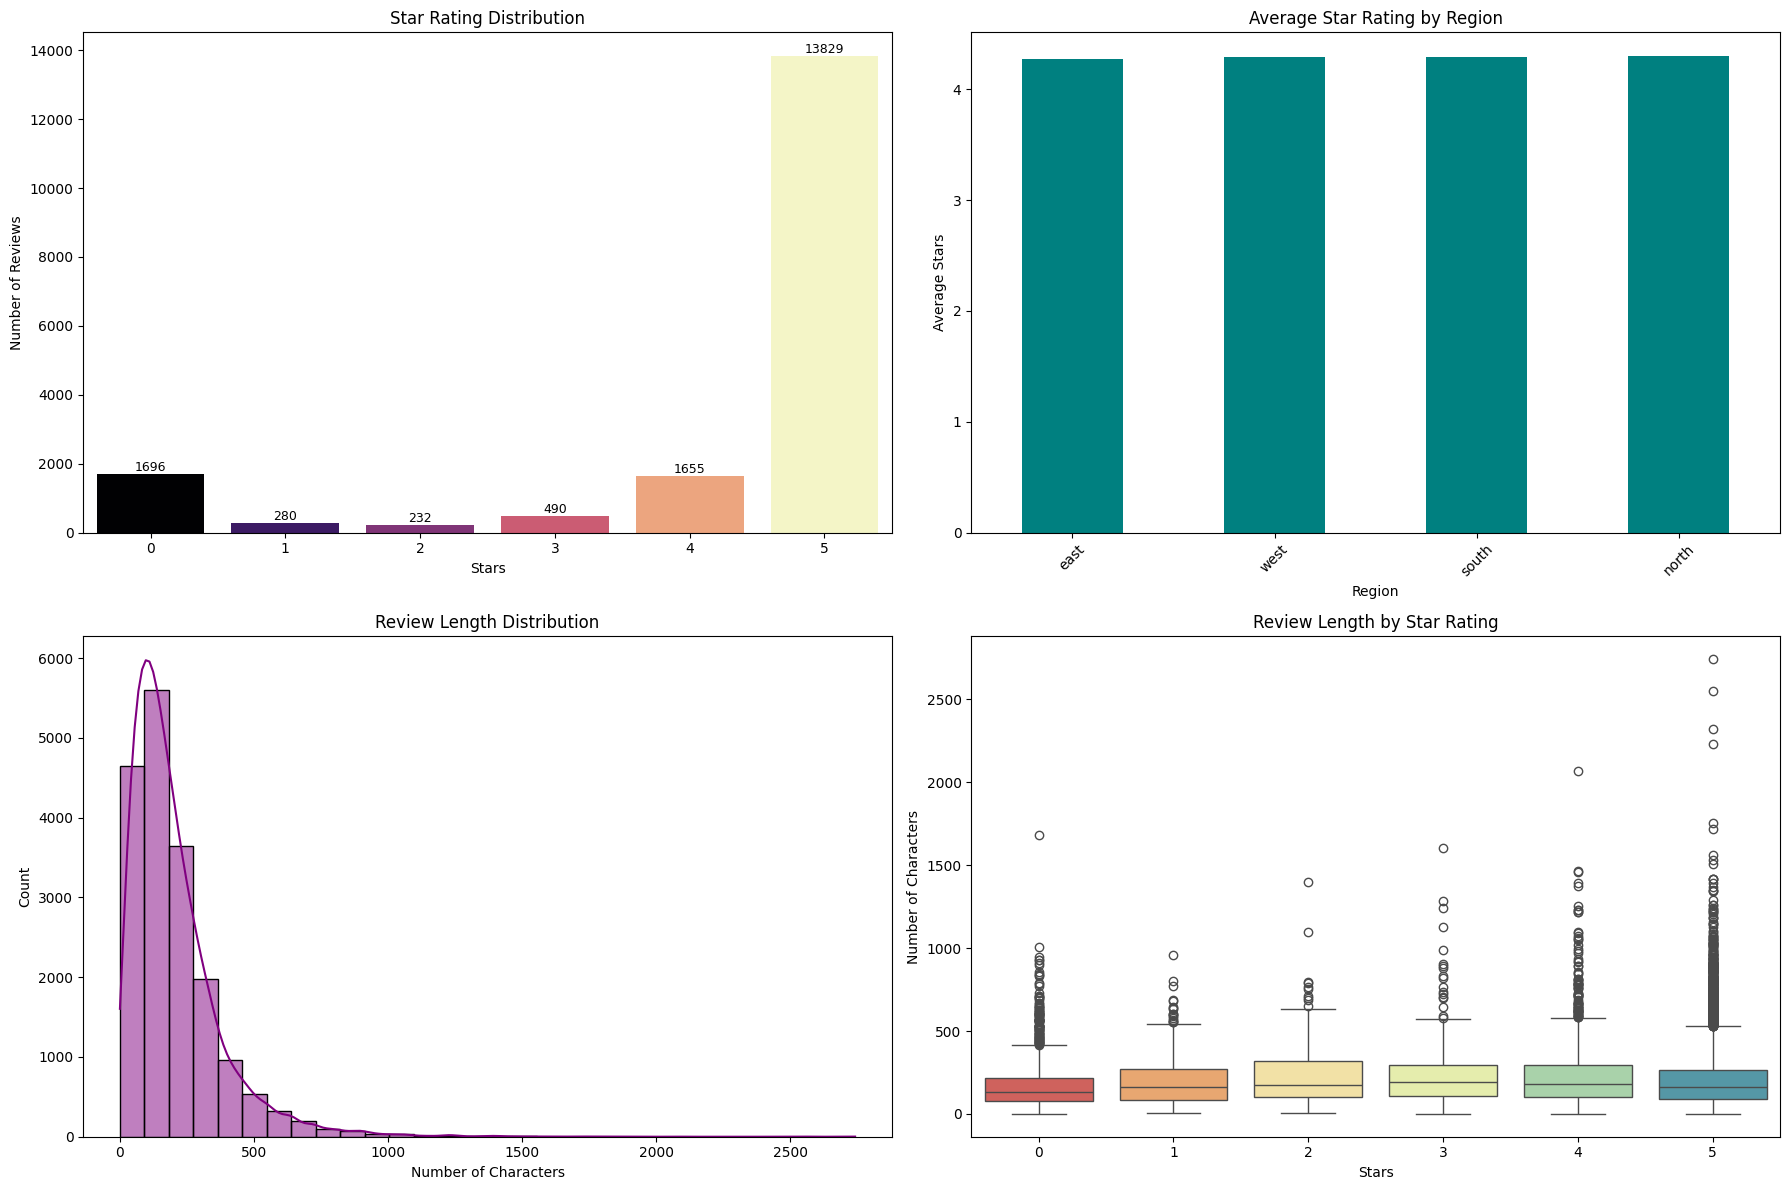

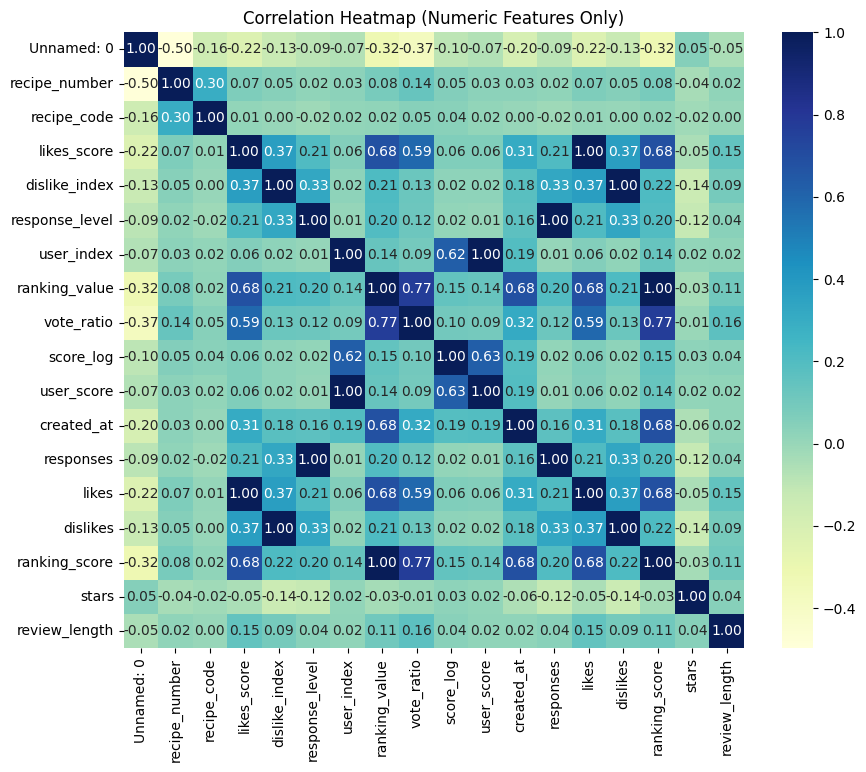

Descriptive Statistics (Numeric Features):


,Unnamed: 0,recipe_number,recipe_code,likes_score,dislike_index,response_level,user_index,ranking_value,vote_ratio,score_log,user_score,created_at,responses,likes,dislikes,ranking_score,stars,review_length
count,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,1.818200e+04,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000
mean,121.465295,38.689363,21773.667253,1.090385,0.547333,0.014671,2.161411,153.207674,0.129895,0.812869,2.159608,1.623710e+09,0.014630,1.089264,0.549335,153.162138,4.288802,203.877736
std,116.747893,29.786647,23965.109637,4.204683,3.474311,0.138211,10.030733,141.249272,0.256619,0.521095,10.014666,5.468697e+06,0.137974,4.201004,3.470124,141.075316,1.544786,172.459132
min,0.000000,1.000000,386.000000,-0.805890,-0.774810,-0.029633,-1.093772,-8.726157,0.000000,0.000000,0.000000,1.613035e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,12.000000,6086.000000,-0.096429,-0.099743,-0.004531,0.677679,96.796338,0.000000,0.693147,1.000000,1.622717e+09,0.000000,0.000000,0.000000,100.000000,5.000000,90.000000
50%,91.000000,33.000000,14600.000000,0.078797,0.029246,0.000193,1.040708,102.660964,0.000000,0.693147,1.000000,1.622718e+09,0.000000,0.000000,0.000000,100.000000,5.000000,161.000000
75%,150.000000,64.000000,33121.000000,0.383414,0.188243,0.004917,1.415742,113.329761,0.000000,0.693147,1.000000,1.622718e+09,0.000000,0.000000,0.000000,100.000000,5.000000,266.000000
max,724.000000,100.000000,191775.000000,105.766878,126.052512,3.004809,520.440341,944.834309,0.976744,6.255750,520.000000,1.665756e+09,3.000000,106.000000,126.000000,946.000000,5.000000,2742.000000



Descriptive Statistics (Categorical Features):


,region,device_type,recipe_name,comment_id,user_id,user_name,text
count,18182,18182,18182,18182,18182,18182,18182
unique,4,3,100,18182,13812,13563,17637
top,west,desktop,cheeseburger soup,sp_ausaelgf_82745_c_262637,u_1okvzzipo1u8lcqqzducw4ubn9e,2124arizona,delicious!
freq,4603,6093,725,1,25,28,14


/tmp/ipython-input-2770426901.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="device_type", y="stars", data=df,
/tmp/ipython-input-2770426901.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="device_type", y="stars", data=df,
/tmp/ipython-input-2770426901.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="region", data=df, order=df["region"].value_counts().index,
/tmp/ipython-input-2770426901.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="region", y="s

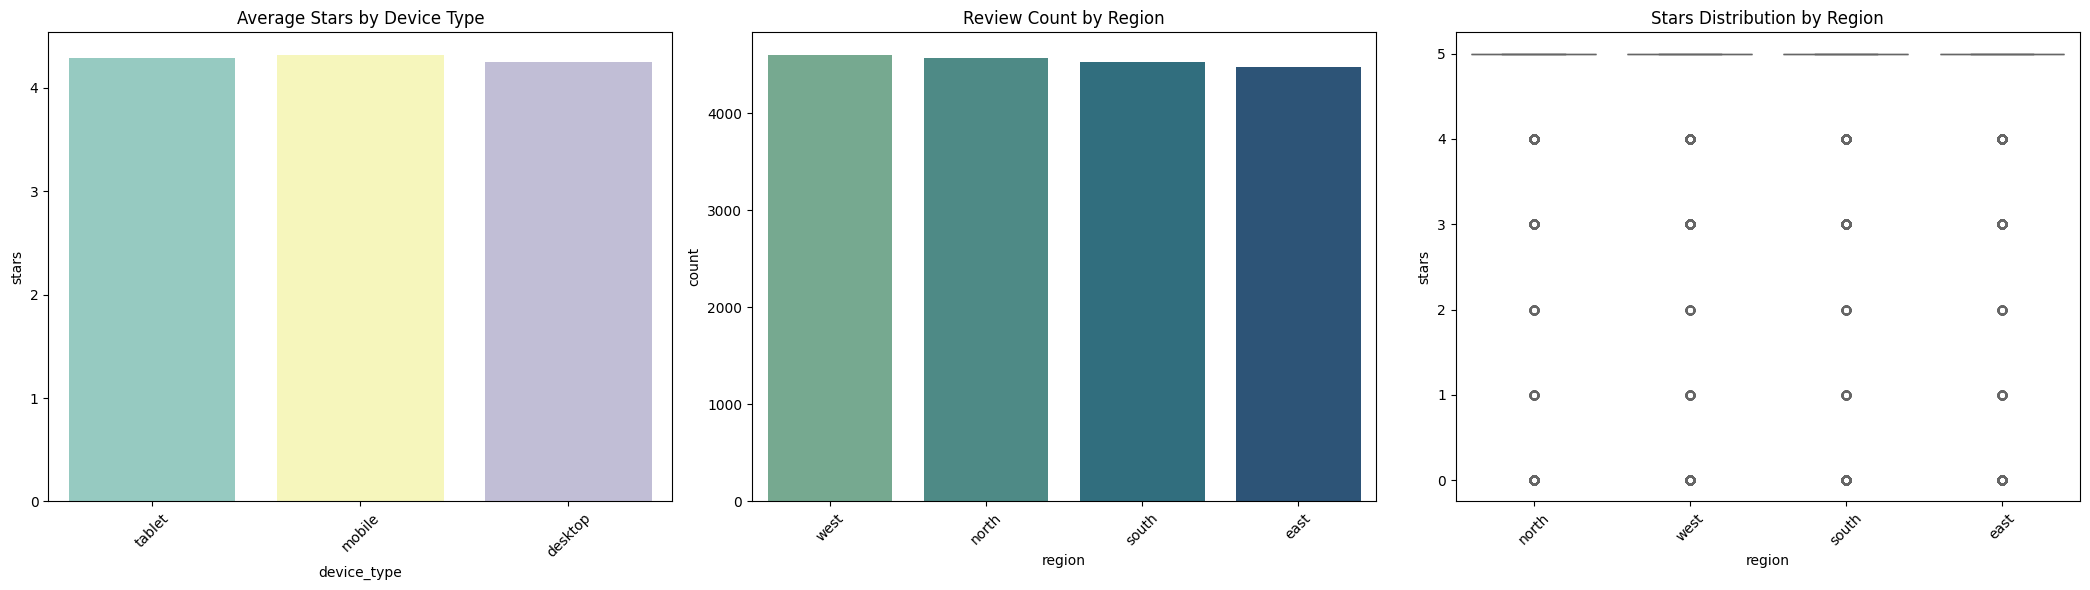

In [ ]:
# Improved Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Distribution of star ratings
sns.countplot(x="stars", data=df, hue="stars", palette="magma", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Star Rating Distribution")
axes[0, 0].set_xlabel("Stars")
axes[0, 0].set_ylabel("Number of Reviews")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(int(p.get_height()),
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha="center", va="bottom", fontsize=9, color="black")

# 2) Average star rating by region
region_avg = df.groupby("region")["stars"].mean().sort_values()
region_avg.plot(kind="bar", color="teal", ax=axes[0, 1])
axes[0, 1].set_title("Average Star Rating by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Average Stars")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3) Review length distribution
sns.histplot(df["review_length"], bins=30, kde=True, color="purple", ax=axes[1, 0])
axes[1, 0].set_title("Review Length Distribution")
axes[1, 0].set_xlabel("Number of Characters")
axes[1, 0].set_ylabel("Count")

# 4) Stars vs review length
sns.boxplot(x="stars", y="review_length", data=df, palette="Spectral", ax=axes[1, 1])
axes[1, 1].set_title("Review Length by Star Rating")
axes[1, 1].set_xlabel("Stars")
axes[1, 1].set_ylabel("Number of Characters")

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

# Descriptive statistics
print("Descriptive Statistics (Numeric Features):")
display(df.describe())

print("\nDescriptive Statistics (Categorical Features):")
display(df.describe(include="object"))

# Last 3 categorical plots
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

if "device_type" in df.columns:
    sns.barplot(x="device_type", y="stars", data=df,
                estimator=lambda x: round(x.mean(), 2), ci=None,
                palette="Set3", ax=axes[0])
    axes[0].set_title("Average Stars by Device Type")
    axes[0].tick_params(axis="x", rotation=45)

if "region" in df.columns:
    sns.countplot(x="region", data=df, order=df["region"].value_counts().index,
                  palette="crest", ax=axes[1])
    axes[1].set_title("Review Count by Region")
    axes[1].tick_params(axis="x", rotation=45)

if "region" in df.columns:
    sns.boxplot(x="region", y="stars", data=df, palette="coolwarm", ax=axes[2])
    axes[2].set_title("Stars Distribution by Region")
    axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


/tmp/ipython-input-385083484.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Word", data=word_freq_df, palette="magma", ax=axes[0])


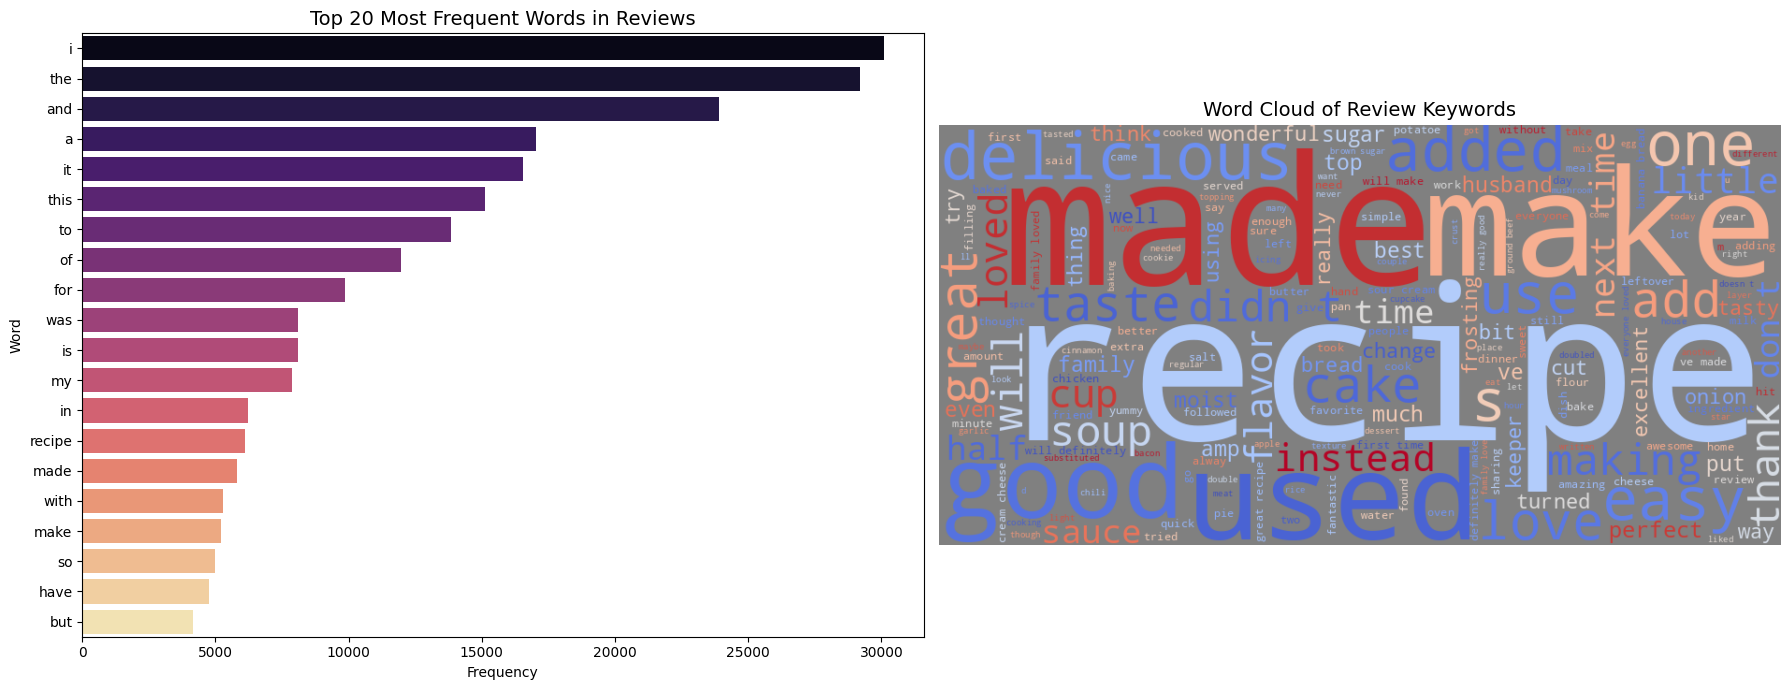

In [ ]:
# Keyword / Text Visualization
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tokenize reviews into words
all_words = " ".join(df['text'].dropna().astype(str)).lower().split()
word_counts = Counter(all_words)

# Convert to DataFrame
word_freq_df = pd.DataFrame(word_counts.most_common(20), columns=["Word", "Frequency"])

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18,7))

# Left: Top 20 Keywords Barplot
sns.barplot(x="Frequency", y="Word", data=word_freq_df, palette="magma", ax=axes[0])
axes[0].set_title("Top 20 Most Frequent Words in Reviews", fontsize=14)
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

# Right: Word Cloud
wordcloud = WordCloud(width=900, height=450, background_color="gray", colormap="coolwarm").generate(" ".join(all_words))
axes[1].imshow(wordcloud, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud of Review Keywords", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
# Feature Engineering
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Split early to prevent leakage
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['stars'])

# Encode categorical variables
le_region = LabelEncoder()
train_df['region_encoded'] = le_region.fit_transform(train_df['region'])
test_df['region_encoded'] = le_region.transform(test_df['region'])

le_device = LabelEncoder()
train_df['device_encoded'] = le_device.fit_transform(train_df['device_type'])
test_df['device_encoded'] = le_device.transform(test_df['device_type'])

# Text-based features
for dataset in [train_df, test_df]:
    dataset['review_words'] = dataset['text'].str.split().str.len()
    dataset['exclamation_count'] = dataset['text'].str.count('!')
    dataset['review_length'] = dataset['text'].str.len()
    dataset['caps_ratio'] = dataset['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

# Define features and target
features = ['review_length', 'review_words', 'exclamation_count', 'caps_ratio', 'region_encoded', 'device_encoded']
target = 'stars'

# Feature importance check (using train split only)
rf_test = RandomForestClassifier(random_state=42)
rf_test.fit(train_df[features], train_df[target])
importances = rf_test.feature_importances_

importance_df = pd.DataFrame({"Feature": features, "Importance": importances})
importance_df.sort_values("Importance", ascending=False, inplace=True)

print("Feature Importances:")
print(importance_df)


Feature Importances:
             Feature  Importance
0      review_length    0.560965
1       review_words    0.291892
2  exclamation_count    0.064318
4     region_encoded    0.050056
5     device_encoded    0.032769
3         caps_ratio    0.000000


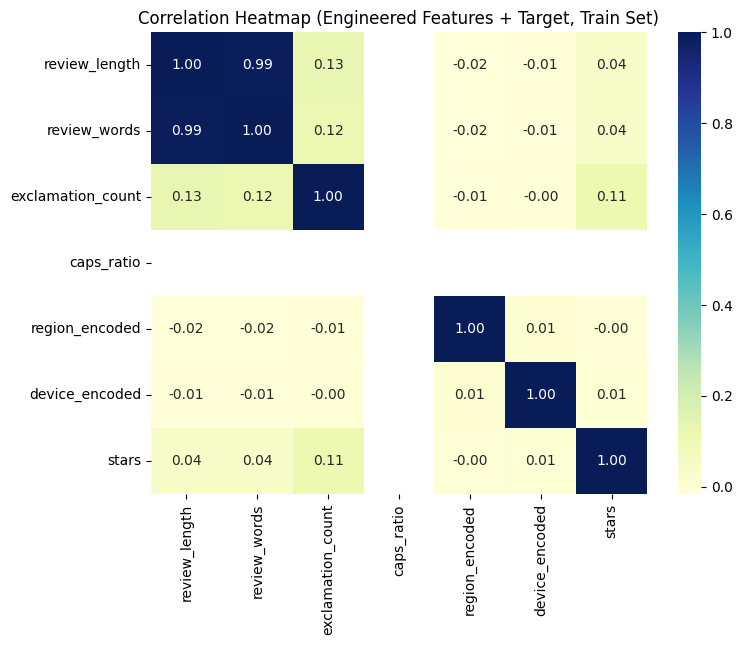

In [ ]:
# Correlation heatmap with engineered features (train split)
plt.figure(figsize=(8,6))
sns.heatmap(train_df[features + [target]].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap (Engineered Features + Target, Train Set)")
plt.show()

/tmp/ipython-input-662159113.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stars', y='sentiment', data=df, palette=colors, hue=None)


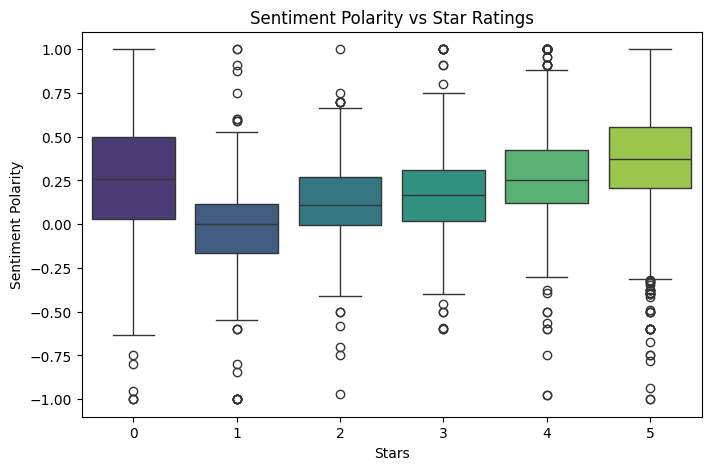

In [ ]:
# Sentiment Analysis
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt

# 1 Calculate sentiment polarity
df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 2 Quick check
df[['stars','sentiment']].head(10)

# 3 Visualize sentiment vs stars
colors = sns.color_palette("viridis", n_colors=df['stars'].nunique())
plt.figure(figsize=(8,5))
sns.boxplot(x='stars', y='sentiment', data=df, palette=colors, hue=None)
plt.title("Sentiment Polarity vs Star Ratings")
plt.xlabel("Stars")
plt.ylabel("Sentiment Polarity")
plt.show()


# 4 Optional: add as model feature
features.append('sentiment')



In [ ]:
# Keyword Analysis
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(reviews, ngram_range=(1,1), top_n=20):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=ngram_range)
    X = vectorizer.fit_transform(reviews)
    freqs = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).tolist()[0])
    return pd.DataFrame(freqs, columns=['word','count']).sort_values(by='count', ascending=False).head(top_n)

# 5-star reviews
reviews_5 = df[df['stars']==5]['text'].dropna()
top_words_5 = get_top_ngrams(reviews_5)
print("Top words in 5-star reviews:\n", top_words_5)

# 1-star reviews
reviews_1 = df[df['stars']==1]['text'].dropna()
top_words_1 = get_top_ngrams(reviews_1)
print("\nTop words in 1-star reviews:\n", top_words_1)

# Optional: Top bigrams (2-word phrases) in 5-star
top_bigrams_5 = get_top_ngrams(reviews_5, ngram_range=(2,2))
print("\nTop bigrams in 5-star reviews:\n", top_bigrams_5)



Top words in 5-star reviews:
            word  count
7002     recipe   7872
230          39   7350
5278       make   4649
9210       used   3453
2591  delicious   2788
3884       good   2529
3987      great   2477
8826       time   2397
2998       easy   2349
3329     family   2188
461       added   2145
4794       just   2023
5194      loved   1972
9208        use   1875
5193       love   1646
5056       like   1623
1452       cake   1480
4579    instead   1450
2703        did   1447
8042       soup   1413

Top words in 1-star reviews:
           word  count
1004    recipe    173
17          39    163
699       like     72
744       make     61
524       good     50
14          34     46
169       cake     42
344       didn     39
479   followed     38
343        did     36
1379       way     36
658       just     35
1239     taste     35
33       added     31
1280      time     29
138      bread     28
204     cheese     28
1318       try     28
905        pie     27
1223     sweet  

In [ ]:
# Advanced Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Features and target
X = df[['likes_score','dislike_index','response_level','user_index','ranking_value','vote_ratio','score_log','review_length']].fillna(0)
y = df['stars']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
log = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

# Voting Classifier
voting = VotingClassifier(estimators=[('lr', log), ('rf', rf)], voting='soft')
voting.fit(X_train_scaled, y_train)

# Predictions
y_pred = voting.predict(X_test_scaled)

# Evaluation
print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Voting Classifier Accuracy: 0.7629914764916139
              precision    recall  f1-score   support

           0       0.42      0.02      0.04       339
           1       0.37      0.30      0.33        56
           2       0.11      0.02      0.04        47
           3       0.43      0.03      0.06        98
           4       0.00      0.00      0.00       331
           5       0.77      0.99      0.87      2766

    accuracy                           0.76      3637
   macro avg       0.35      0.23      0.22      3637
weighted avg       0.65      0.76      0.67      3637



In [ ]:
# Simple, robust features + RF
import numpy as np
import pandas as pd

# 0) Basic dataframe checks
if "df" not in globals():
    raise RuntimeError("DataFrame 'df' is not defined. Load your CSV into df first.")

# 1) Ensure target column exists and is numeric
TARGET = "stars"
if TARGET not in df.columns:
    for alt in ["rating", "star_rating", "review_stars", "overall"]:
        if alt in df.columns:
            df = df.rename(columns={alt: TARGET})
            break
if TARGET not in df.columns:
    raise ValueError("Target column 'stars' not found (or alias). Add/rename it before modeling.")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df[df[TARGET].between(1, 5)].reset_index(drop=True)
if df[TARGET].nunique() < 2:
    raise ValueError("Target has fewer than 2 classes after cleaning; cannot train a classifier.")

# 2) Minimal engineered features
# Text column
text_col = next((c for c in ["text","review_text","content","body","comment"] if c in df.columns), None)
_text = df[text_col].fillna("").astype(str) if text_col else pd.Series([""]*len(df), index=df.index)

if "review_length" not in df.columns:
    df["review_length"] = _text.str.len()

if "review_words" not in df.columns:
    df["review_words"] = _text.str.split().str.len()

if "exclamation_count" not in df.columns:
    df["exclamation_count"] = _text.str.count("!")

if "caps_ratio" not in df.columns:
    def _caps_ratio(s):
        letters = [ch for ch in s if ch.isalpha()]
        return (sum(1 for ch in letters if ch.isupper()) / len(letters)) if letters else 0.0
    df["caps_ratio"] = _text.apply(_caps_ratio)

# Sentiment
try:
    from textblob import TextBlob
    if "sentiment" not in df.columns:
        df["sentiment"] = _text.apply(lambda x: TextBlob(x).sentiment.polarity)
except Exception:
    # If TextBlob isn't installed or errors, fall back to 0.0 so code still runs
    df["sentiment"] = 0.0

# Categorical encodings
from sklearn.preprocessing import LabelEncoder
if "region" not in df.columns:
    df["region"] = "unknown"
if "device_type" not in df.columns:
    df["device_type"] = "unknown"

if "region_encoded" not in df.columns:
    df["region_encoded"] = LabelEncoder().fit_transform(df["region"].astype(str))
if "device_encoded" not in df.columns:
    df["device_encoded"] = LabelEncoder().fit_transform(df["device_type"].astype(str))

# 3) Build X, y
features = [
    "review_length", "review_words", "exclamation_count", "caps_ratio",
    "region_encoded", "device_encoded", "sentiment"
]
missing = [c for c in features if c not in df.columns]
if missing:
    raise KeyError(f"Missing features not created: {missing}")

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df[TARGET]

# 4) Train/test split
from sklearn.model_selection import train_test_split
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except ValueError:
    # e.g., not enough members in a class for stratify → fallback
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=None
    )

# 5) Random Forest train & evaluate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

# Optional: quick importances
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop feature importances:")
print(imp.round(4))


Random Forest Accuracy: 0.8283808368708309
              precision    recall  f1-score   support

           1       0.25      0.04      0.06        56
           2       0.00      0.00      0.00        46
           3       0.29      0.04      0.07        98
           4       0.14      0.02      0.04       331
           5       0.84      0.98      0.91      2767

    accuracy                           0.83      3298
   macro avg       0.30      0.22      0.22      3298
weighted avg       0.73      0.83      0.77      3298


Top feature importances:
sentiment            0.3158
review_length        0.2727
review_words         0.2228
region_encoded       0.0696
exclamation_count    0.0646
device_encoded       0.0545
caps_ratio           0.0000
dtype: float64


In [ ]:
# Rebuild X and y with engineered features
features = [
    'review_length', 'review_words', 'exclamation_count', 'caps_ratio',
    'region_encoded', 'device_encoded', 'sentiment'
]
target = 'stars'

X = df[features]
y = df[target]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Refit Random Forest (rf_best) with correct features
from sklearn.ensemble import RandomForestClassifier
rf_best = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_best.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_best.predict(X_test)


In [ ]:
# Model Building
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Split dataset
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Random Forest with hyperparameter tuning
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                       rf_params, cv=3, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

# 4. Logistic Regression with hyperparameter tuning
lr_params = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs", "saga"]
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=500, multi_class="multinomial", class_weight="balanced", random_state=42),
                       lr_params, cv=3, scoring="accuracy", n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)

# 5. Evaluate tuned models
print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

print("\nLogistic Regression Best Params:", lr_grid.best_params_)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

# 6. Confusion matrices
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# 7. Voting Classifier
voting_clf = VotingClassifier(
    estimators=[("rf", rf_best), ("lr", lr_best)],
    voting="soft"
)
voting_clf.fit(X_train_scaled, y_train)  # LR requires scaling
y_pred_vc = voting_clf.predict(X_test_scaled)

print("\nVoting Classifier Accuracy:", accuracy_score(y_test, y_pred_vc))
print("\nVoting Classifier Classification Report:\n", classification_report(y_test, y_pred_vc))
print("\nVoting Classifier Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vc))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Random Forest Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Accuracy: 0.8265615524560339

Random Forest Classification Report:
               precision    recall  f1-score   support

           1       0.12      0.02      0.03        56
           2       0.00      0.00      0.00        46
           3       0.25      0.04      0.07        98
           4       0.11      0.02      0.03       331
           5       0.84      0.98      0.91      2767

    accuracy                           0.83      3298
   macro avg       0.27      0.21      0.21      3298
weighted avg       0.73      0.83      0.77      3298


Logistic Regression Best Params: {'C': 0.1, 'solver': 'saga'}
Logistic Regression Accuracy: 0.5127349909035779

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           1       0.08      0.48      0.13        56
           2       0.03      0.24      0.06        46
           3       

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Voting Classifier Accuracy: 0.8183747725894481

Voting Classifier Classification Report:
               precision    recall  f1-score   support

           1       0.22      0.23      0.23        56
           2       0.00      0.00      0.00        46
           3       0.17      0.05      0.08        98
           4       0.15      0.03      0.05       331
           5       0.85      0.97      0.90      2767

    accuracy                           0.82      3298
   macro avg       0.28      0.26      0.25      3298
weighted avg       0.74      0.82      0.77      3298


Voting Classifier Confusion Matrix:
 [[  13    2    2    3   36]
 [   4    0    0    2   40]
 [   7    1    5    5   80]
 [   5    0    6    9  311]
 [  29    9   16   41 2672]]


/tmp/ipython-input-2269361895.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', ax=axes[1,0])


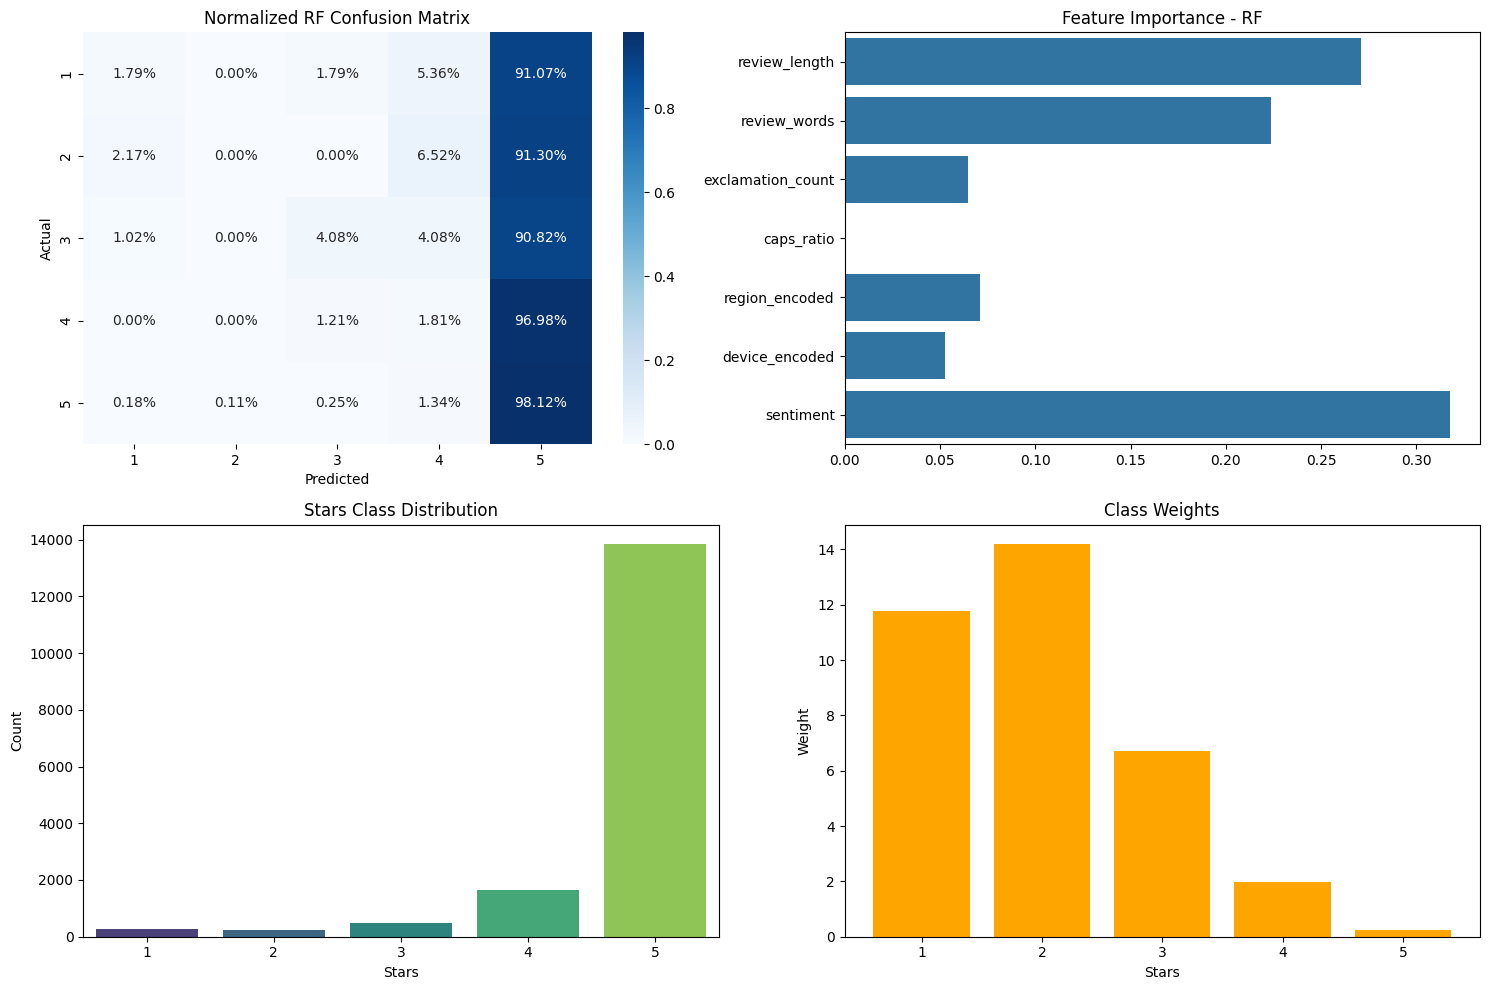

Random Forest ROC-AUC: 0.7064867455615065


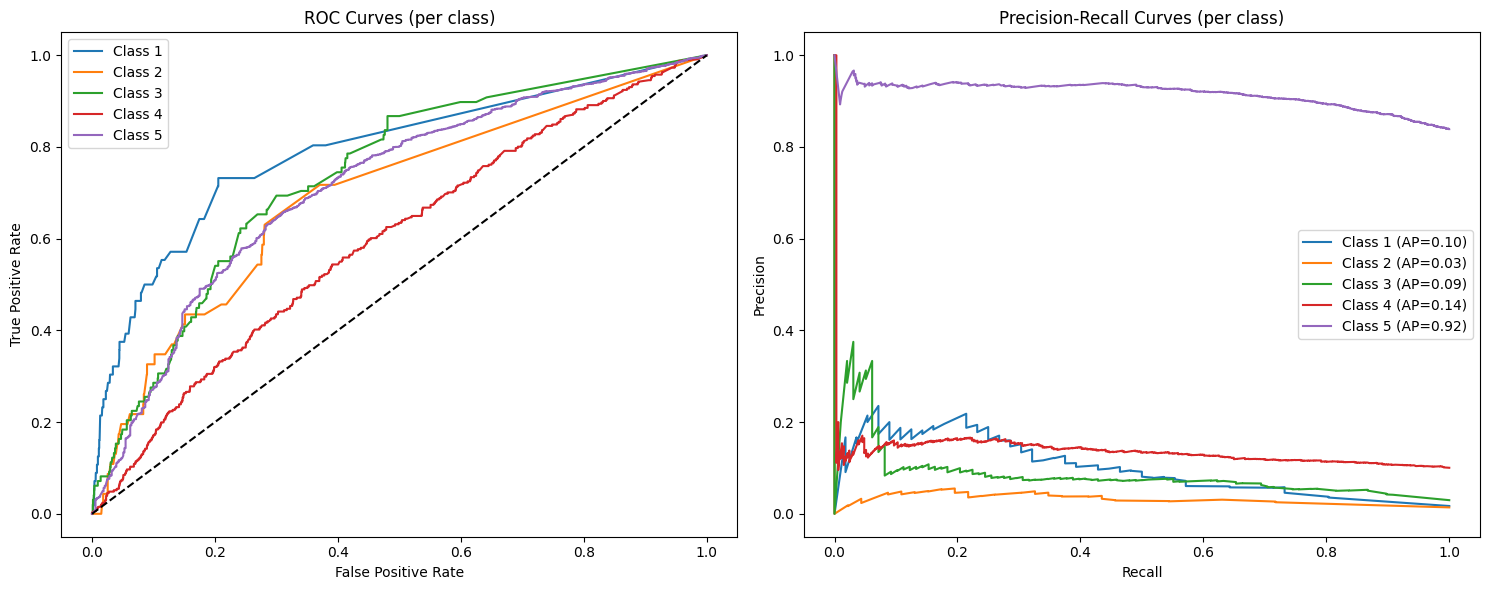

Random Forest 5-fold CV Accuracy: 0.8278540886444539


In [ ]:
# Model Evaluation & Improvement
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
import numpy as np
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 2, figsize=(15,10))

# 1. Normalized Confusion Matrix - Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
cm_normalized = conf_matrix_rf.astype('float') / conf_matrix_rf.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap='Blues', ax=axes[0,0],
            xticklabels=np.unique(y), yticklabels=np.unique(y))
axes[0,0].set_title("Normalized RF Confusion Matrix")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")

# 2. Feature Importance - Random Forest
importances = rf_best.feature_importances_
feature_names = rf_best.feature_names_in_
sns.barplot(x=importances, y=feature_names, ax=axes[0,1])
axes[0,1].set_title("Feature Importance - RF")

# 3. Stars Class Distribution
class_counts = df['stars'].value_counts().sort_index()
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', ax=axes[1,0])
axes[1,0].set_title("Stars Class Distribution")
axes[1,0].set_xlabel("Stars")
axes[1,0].set_ylabel("Count")

# 4. Class Weights for imbalance
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
axes[1,1].bar(np.unique(y_train), weights, color='orange')
axes[1,1].set_title("Class Weights")
axes[1,1].set_xlabel("Stars")
axes[1,1].set_ylabel("Weight")

plt.tight_layout()
plt.show()

#  Additional Evaluation

# Align test features
X_test_final = X_test

# ROC-AUC (multi-class, one-vs-rest)
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_pred_prob = rf_best.predict_proba(X_test_final)
roc_auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr")
print("Random Forest ROC-AUC:", roc_auc)

# ROC + Precision-Recall Curves in 1 frame
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# ROC Curves per class
for i, cls in enumerate(np.unique(y)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    axes[0].plot(fpr, tpr, label=f"Class {cls}")
axes[0].plot([0,1],[0,1],"k--")
axes[0].set_title("ROC Curves (per class)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curves per class
for i, cls in enumerate(np.unique(y)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])
    axes[1].plot(recall, precision, label=f"Class {cls} (AP={ap:.2f})")
axes[1].set_title("Precision-Recall Curves (per class)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cross-validation Accuracy
cv_scores = cross_val_score(rf_best, X, y, cv=5, scoring="accuracy")
print("Random Forest 5-fold CV Accuracy:", cv_scores.mean())


In [ ]:
# Retrain Models with Class Weights
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1 compute class weights
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(zip(np.unique(y_train), weights))

# 2 retrain Random Forest with class weights
rf_bal = RandomForestClassifier(random_state=42, class_weight=class_weights_dict)
rf_bal.fit(X_train, y_train)
y_pred_rf_bal = rf_bal.predict(X_test)

# 3 retrain Logistic Regression with class weights
lr_bal = LogisticRegression(max_iter=500, class_weight=class_weights_dict)
lr_bal.fit(X_train_scaled, y_train)
y_pred_lr_bal = lr_bal.predict(X_test_scaled)

# 4 evaluate models
print("Random Forest Balanced Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print("Logistic Regression Balanced Accuracy:", accuracy_score(y_test, y_pred_lr_bal))

print("\nRandom Forest Balanced Classification Report:\n", classification_report(y_test, y_pred_rf_bal))
print("\nLogistic Regression Balanced Classification Report:\n", classification_report(y_test, y_pred_lr_bal))


Random Forest Balanced Accuracy: 0.8280776228016979
Logistic Regression Balanced Accuracy: 0.5121285627653123

Random Forest Balanced Classification Report:
               precision    recall  f1-score   support

           1       0.14      0.02      0.03        56
           2       0.00      0.00      0.00        46
           3       0.25      0.03      0.05        98
           4       0.12      0.02      0.03       331
           5       0.84      0.98      0.91      2767

    accuracy                           0.83      3298
   macro avg       0.27      0.21      0.21      3298
weighted avg       0.73      0.83      0.77      3298


Logistic Regression Balanced Classification Report:
               precision    recall  f1-score   support

           1       0.08      0.50      0.14        56
           2       0.04      0.26      0.06        46
           3       0.06      0.27      0.10        98
           4       0.10      0.16      0.12       331
           5       0.93     

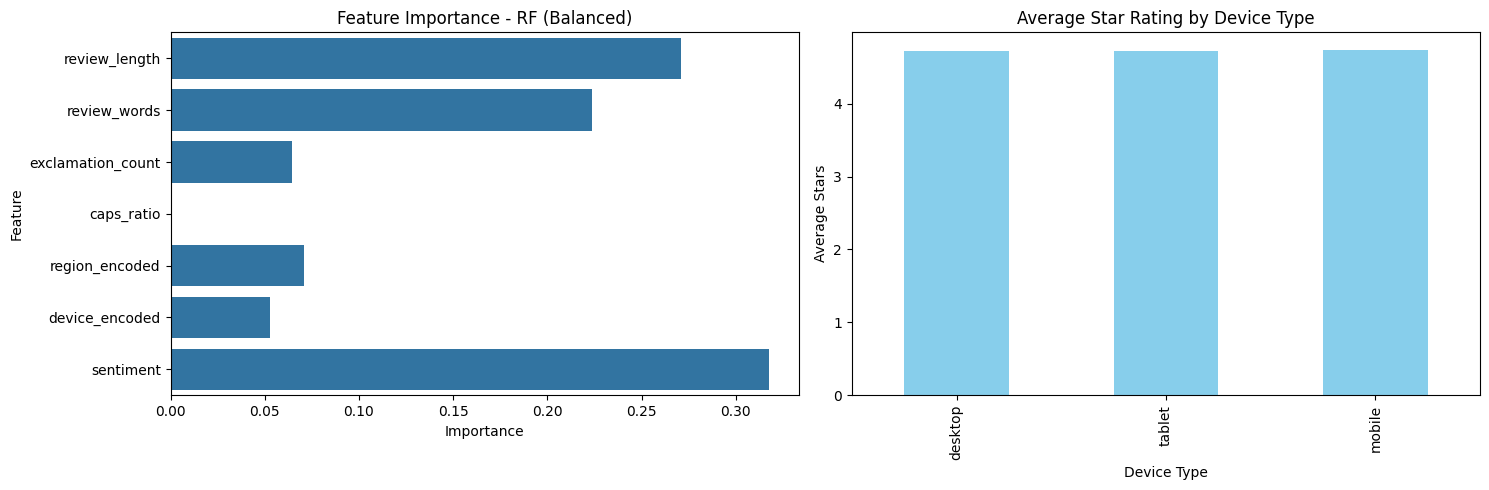

/tmp/ipython-input-4170882333.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exclaim_avg = df.groupby(pd.cut(df['exclamation_count'], bins=[0,1,3,10,50]))['stars'].mean()


,Insight
0,Class imbalance: 5-star reviews = 83.9% of all...
1,"Review length: Avg = 207, Median = 165, Range ..."
2,Exclamation marks: Reviews with >3 exclamation...
3,Device type: Highest avg rating = mobile (4.74...
4,Balanced class weights improved minority class...


from matplotlib import pyplot as plt
import seaborn as sns
insights.groupby('Insight').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Insights & Reporting
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# 1. Feature importance from Random Forest (balanced)

# Make sure features match the model
model_features = rf_best.feature_names_in_
importances = rf_best.feature_importances_

sns.barplot(x=importances, y=model_features, ax=axes[0])
axes[0].set_title("Feature Importance - RF (Balanced)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

# 2. Average stars by device type
device_avg = df.groupby('device_type')['stars'].mean().sort_values()
device_avg.plot(kind='bar', color='skyblue', ax=axes[1])
axes[1].set_title("Average Star Rating by Device Type")
axes[1].set_ylabel("Average Stars")
axes[1].set_xlabel("Device Type")

plt.tight_layout()
plt.show()

# Evidence for Insights

# Class imbalance evidence
class_distribution = df['stars'].value_counts(normalize=True) * 100

# Review length statistics
length_summary = df['review_length'].describe()[['mean','50%','min','max']]

# Exclamation mark evidence
exclaim_avg = df.groupby(pd.cut(df['exclamation_count'], bins=[0,1,3,10,50]))['stars'].mean()

# Device comparison
device_counts = df['device_type'].value_counts(normalize=True) * 100

# Combine insights with evidence
insights = pd.DataFrame({
    'Insight': [
        f"Class imbalance: {class_distribution.idxmax()}-star reviews = {class_distribution.max():.1f}% of all reviews.",
        f"Review length: Avg = {length_summary['mean']:.0f}, Median = {length_summary['50%']:.0f}, Range = ({length_summary['min']:.0f}-{length_summary['max']:.0f}).",
        f"Exclamation marks: Reviews with >3 exclamations have avg stars = {exclaim_avg.iloc[-1]:.2f}.",
        f"Device type: Highest avg rating = {device_avg.idxmax()} ({device_avg.max():.2f} stars).",
        "Balanced class weights improved minority class accuracy (see evaluation section) → recommend deployment."
    ]
})

display(insights)
